<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1789 | Val: 434 | Test: 284


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 1.475
  Empty          : 1.602
  Functional     : 0.450
  Scum           : 0.473


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.7779 acc 0.677 | val loss 0.7069 acc 0.730 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.4430 acc 0.804 | val loss 0.4986 acc 0.816 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.3567 acc 0.849 | val loss 0.9461 acc 0.710


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.2922 acc 0.866 | val loss 0.5948 acc 0.793


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.2915 acc 0.884 | val loss 0.5006 acc 0.809


...

[ResNet-18] Epoch  14/100 | LR: 1.25e-04 | train loss 0.0067 acc 0.998 | val loss 0.5432 acc 0.853


[ResNet-18] Epoch  15/100 | LR: 1.25e-04 | train loss 0.0037 acc 0.999 | val loss 0.5135 acc 0.855


[ResNet-18] Epoch  16/100 | LR: 6.25e-05 | train loss 0.0042 acc 0.998 | val loss 0.5124 acc 0.855


[ResNet-18] Epoch  17/100 | LR: 6.25e-05 | train loss 0.0036 acc 0.999 | val loss 0.5196 acc 0.857


[ResNet-18] Epoch  18/100 | LR: 6.25e-05 | train loss 0.0046 acc 0.998 | val loss 0.5124 acc 0.857

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 18.

[ResNet-18] Restored best checkpoint (val loss = 0.3649)


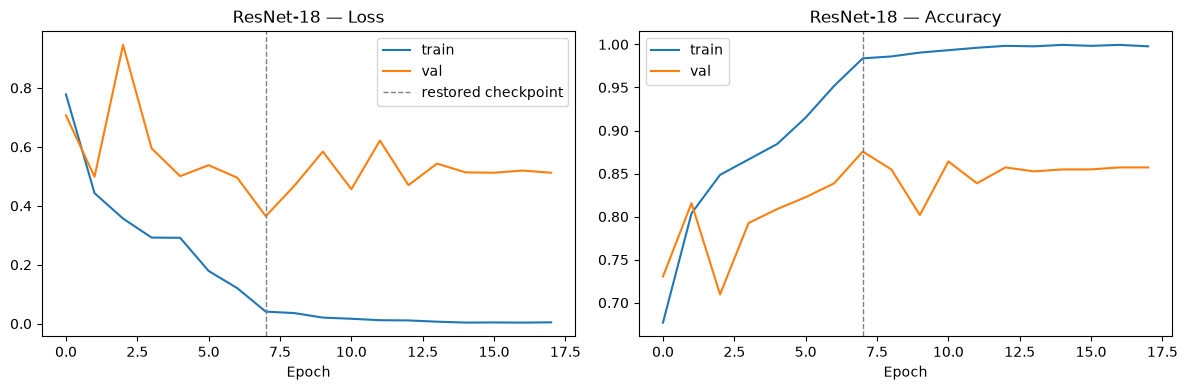

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.824


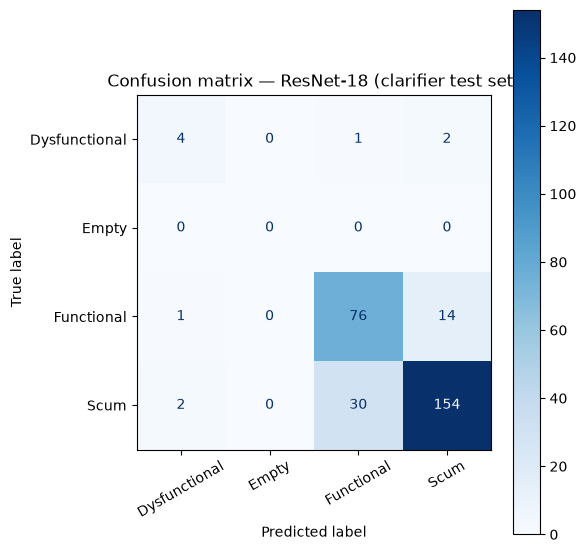

               precision    recall  f1-score   support

Dysfunctional      0.571     0.571     0.571         7
        Empty      0.000     0.000     0.000         0
   Functional      0.710     0.835     0.768        91
         Scum      0.906     0.828     0.865       186

     accuracy                          0.824       284
    macro avg      0.547     0.559     0.551       284
 weighted avg      0.835     0.824     0.827       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


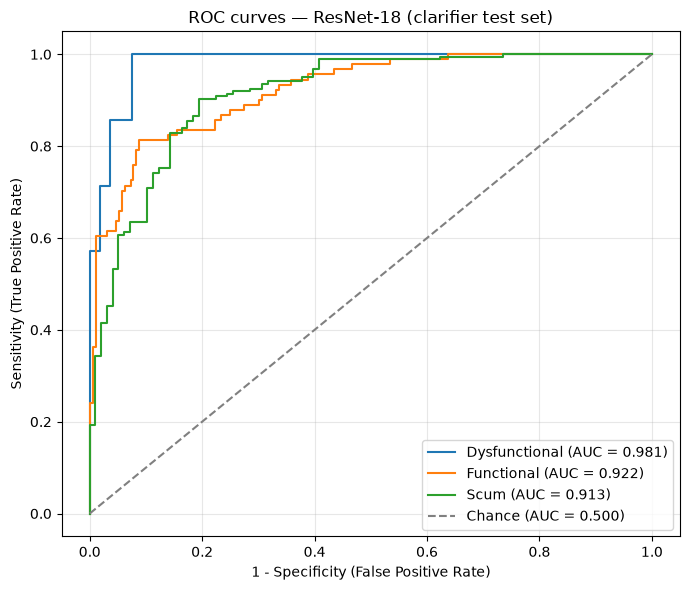

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.981
  Empty          : undefined (0 examples)
  Functional     : 0.922
  Scum           : 0.913

Mean AUC (over 3/4 classes with test examples): 0.939


(np.float64(0.823943661971831),
 {'Dysfunctional': 0.9814337287261475,
  'Empty': nan,
  'Functional': 0.9217104139383933,
  'Scum': 0.9127166995830591})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_Waterval.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
